In [32]:
import sys
!{sys.executable} -m pip install matplotlib

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from data import load_all_datasets, normalize_tag

1.0 EDA 
- Basic Statistics about Datasets (num_sentences, num_tokens, avg_sentence_length)
- Plotting the number of tokens per dataset split
- Label distribution across datasets
- Label precentage  across datasets
- Plotting the percentage of entity tokens across datasets
- Train/dev/test consistency check

In [34]:
datasets = load_all_datasets("data")

  ewt    — train: 12543, dev: 2001, test: 2077
  conll  — train: 14041, dev: 3250, test: 3453
  wiesp  — train: 1816, dev: 1405, test: 2549


In [35]:
# Basic statistics about the datasets
rows = []

for domain_name, splits in datasets.items():
    for split_name, sentences in splits.items():
        sentence_lengths = [len(sentence["tokens"]) for sentence in sentences]

        rows.append({
            "domain": domain_name,
            "split": split_name,
            "num_sentences": len(sentences),
            "num_tokens": sum(sentence_lengths),
            "avg_sentence_length": round(sum(sentence_lengths) / len(sentence_lengths), 2),
            "median_sentence_length": int(pd.Series(sentence_lengths).median()),
            "max_sentence_length": max(sentence_lengths),
        })

basic_stats_df = pd.DataFrame(rows)
basic_stats_df

,domain,split,num_sentences,num_tokens,avg_sentence_length,median_sentence_length,max_sentence_length
0,ewt,train,12543,204579,16.31,14,159
1,ewt,dev,2001,25149,12.57,10,75
2,ewt,test,2077,25097,12.08,9,81
3,conll,train,14041,203621,14.50,10,113
4,conll,dev,3250,51362,15.80,11,109
5,conll,test,3453,46435,13.45,9,124
6,wiesp,train,1816,573068,315.57,443,795
7,wiesp,dev,1405,447321,318.38,433,727
8,wiesp,test,2549,794687,311.76,310,884


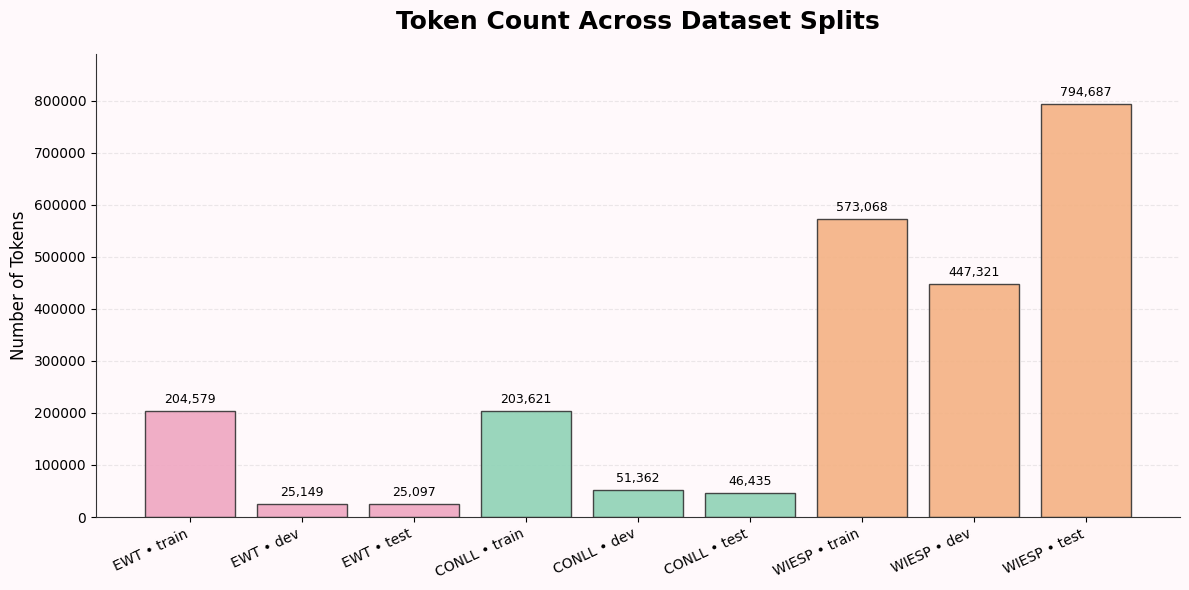

In [36]:
import matplotlib.pyplot as plt

domain_colors = {
    "ewt": "#EFA6C1",     # pink
    "conll": "#8FD3B6",   # mint
    "wiesp": "#F4B183"    # peach
}

basic_stats_df["dataset"] = (
    basic_stats_df["domain"].str.upper()
    + " • "
    + basic_stats_df["split"]
)

bar_colors = basic_stats_df["domain"].map(domain_colors)

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor("#fff9fb")
ax.set_facecolor("#fff9fb")

bars = ax.bar(
    basic_stats_df["dataset"],
    basic_stats_df["num_tokens"],
    color=bar_colors,
    edgecolor="#333333",
    linewidth=1,
    alpha=0.9
)

ax.set_title(
    "Token Count Across Dataset Splits",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_ylabel("Number of Tokens", fontsize=12)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#333333")
ax.spines["bottom"].set_color("#333333")

plt.xticks(rotation=25, ha="right", fontsize=10)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + basic_stats_df["num_tokens"].max() * 0.012,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_ylim(0, basic_stats_df["num_tokens"].max() * 1.12)

plt.tight_layout()
plt.show()

In [38]:
# Label distribution across datasets
label_rows = []

for domain_name, splits in datasets.items():
    for split_name, sentences in splits.items():
        label_counter = Counter()

        for sentence in sentences:
            normalized_tags = [normalize_tag(tag) for tag in sentence["ner_tags"]]
            label_counter.update(normalized_tags)

        total_labels = sum(label_counter.values())

        for label, count in label_counter.items():
            label_rows.append({
                "domain": domain_name,
                "split": split_name,
                "label": label,
                "count": count,
                "percentage": round((count / total_labels) * 100, 2),
            })

label_dist_df = pd.DataFrame(label_rows)
label_dist_df.sort_values(["domain", "split", "count"], ascending=[True, True, False])

,domain,split,label,count,percentage
22,conll,dev,O,44027,85.72
25,conll,dev,B-PER,1842,3.59
24,conll,dev,B-LOC,1837,3.58
23,conll,dev,B-ORG,1341,2.61
26,conll,dev,I-PER,1307,2.54
...,...,...,...,...,...
60,wiesp,train,B-Event,45,0.01
91,wiesp,train,I-Identifier,28,0.00
92,wiesp,train,I-Mission,27,0.00
98,wiesp,train,I-EntityOfFutureInterest,16,0.00


In [39]:
# Label precentage  across datasets
entity_rows = []

for domain_name, splits in datasets.items():
    for split_name, sentences in splits.items():
        label_counter = Counter()

        for sentence in sentences:
            normalized_tags = [normalize_tag(tag) for tag in sentence["ner_tags"]]
            label_counter.update(normalized_tags)

        total_tokens = sum(label_counter.values())
        o_tokens = label_counter["O"]
        entity_tokens = total_tokens - o_tokens

        entity_rows.append({
            "domain": domain_name,
            "split": split_name,
            "total_tokens": total_tokens,
            "O_tokens": o_tokens,
            "entity_tokens": entity_tokens,
            "O_percentage": round((o_tokens / total_tokens) * 100, 2),
            "entity_percentage": round((entity_tokens / total_tokens) * 100, 2),
        })

entity_ratio_df = pd.DataFrame(entity_rows)
entity_ratio_df

,domain,split,total_tokens,O_tokens,entity_tokens,O_percentage,entity_percentage
0,ewt,train,204579,194219,10360,94.94,5.06
1,ewt,dev,25149,23653,1496,94.05,5.95
2,ewt,test,25097,25097,0,100.00,0.00
3,conll,train,203621,174171,29450,85.54,14.46
4,conll,dev,51362,44027,7335,85.72,14.28
5,conll,test,46435,39241,7194,84.51,15.49
6,wiesp,train,573068,472273,100795,82.41,17.59
7,wiesp,dev,447321,365524,81797,81.71,18.29
8,wiesp,test,794687,639736,154951,80.50,19.50


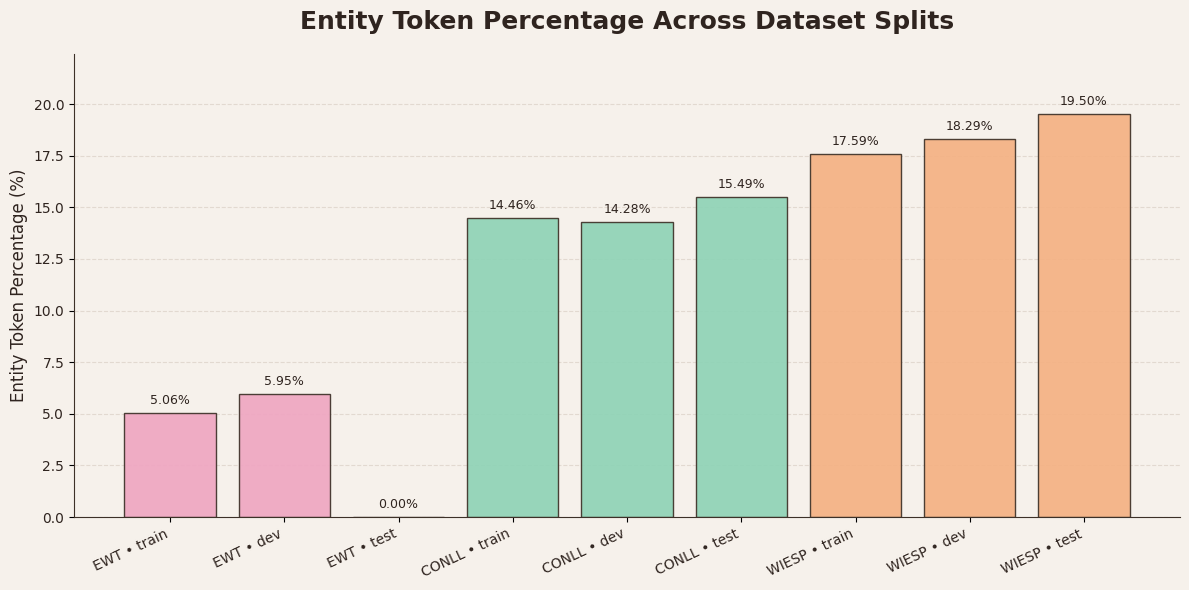

In [40]:
import matplotlib.pyplot as plt

domain_colors = {
    "ewt": "#EFA6C1",
    "conll": "#8FD3B6",
    "wiesp": "#F4B183"
}

entity_ratio_df["dataset"] = (
    entity_ratio_df["domain"].str.upper()
    + " • "
    + entity_ratio_df["split"]
)

bar_colors = entity_ratio_df["domain"].map(domain_colors)

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor("#f6f1eb")
ax.set_facecolor("#f6f1eb")

bars = ax.bar(
    entity_ratio_df["dataset"],
    entity_ratio_df["entity_percentage"],
    color=bar_colors,
    edgecolor="#3d3128",
    linewidth=1,
    alpha=0.92
)

ax.set_title(
    "Entity Token Percentage Across Dataset Splits",
    fontsize=18,
    fontweight="bold",
    pad=18,
    color="#2f241f"
)

ax.set_ylabel("Entity Token Percentage (%)", fontsize=12, color="#2f241f")

ax.grid(axis="y", linestyle="--", alpha=0.18, color="#8b6f5a")
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#3d3128")
ax.spines["bottom"].set_color("#3d3128")

plt.xticks(rotation=25, ha="right", fontsize=10, color="#2f241f")
plt.yticks(color="#2f241f")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + entity_ratio_df["entity_percentage"].max() * 0.015,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#2f241f"
    )

ax.set_ylim(0, entity_ratio_df["entity_percentage"].max() * 1.15)

plt.tight_layout()
plt.show()

In [42]:
# Train/dev/test consistency check
label_split_comparison = label_dist_df.pivot_table(
    index=["domain", "label"],
    columns="split",
    values="percentage",
    fill_value=0
)

label_split_comparison

#Why it matters, Model trains on train distribution - If test is very different → performance drops / misleading results

split                   dev   test  train
domain label                             
conll  B-LOC           3.58   3.59   3.51
       B-ORG           2.61   3.58   3.10
       B-PER           3.59   3.48   3.24
       I-LOC           0.50   0.55   0.57
       I-ORG           1.46   1.80   1.82
...                     ...    ...    ...
wiesp  I-Telescope     0.13   0.12   0.11
       I-TextGarbage   0.01   0.03   0.01
       I-URL           0.00   0.01   0.00
       I-Wavelength    0.42   0.34   0.28
       O              81.71  80.50  82.41

[77 rows x 3 columns]

2.0 EDA
- Vocabulary statistics
- Most common words
- Rare words
- Vocabulary overlap between domains
- Entity type distribution
- Most common entities
- Most common entities per datasets

In [43]:
# Vocabulary statistics 
#    vocab_size - Number of unique tokens (words) exactly as they appear (case sensitive words)
#    lower_vocab_size - Number of unique tokens when converted to lowercase (to check case sensitivity) 

def get_vocab_stats(sentences):
    tokens = []
    for sent in sentences:
        tokens.extend(sent["tokens"])

    vocab = set(tokens)
    lower_vocab = set(t.lower() for t in tokens)

    return {
        "num_tokens": len(tokens),
        "vocab_size": len(vocab),
        "lower_vocab_size": len(lower_vocab),
    }


rows = []

for domain_name, splits in datasets.items():
    train_sentences = splits["train"]

    stats = get_vocab_stats(train_sentences)

    rows.append({
        "domain": domain_name,
        **stats
    })

vocab_df = pd.DataFrame(rows)
vocab_df

,domain,num_tokens,vocab_size,lower_vocab_size
0,ewt,204579,19673,16654
1,conll,203621,23623,21009
2,wiesp,573068,48952,45714


In [44]:
# Most common words in each dataset split - To check for domain-specific words and stopwords
def most_common_words(sentences, n=20):
    counter = Counter()

    for sent in sentences:
        words = [w.lower() for w in sent["tokens"]]
        counter.update(words)

    return counter.most_common(n)


for domain_name, splits in datasets.items():
    print(f"\nTop words in {domain_name}_train:")
    print(most_common_words(splits["train"], 20))


Top words in ewt_train:
[('the', 9076), ('.', 8640), (',', 7021), ('to', 5137), ('and', 5002), ('a', 3782), ('of', 3622), ('i', 3379), ('in', 3112), ('is', 2239), ('you', 2156), ('that', 2036), ('it', 1850), ('for', 1842), ('-', 1423), ('have', 1357), ('"', 1296), ('on', 1273), ('was', 1244), ('with', 1216)]

Top words in conll_train:
[('the', 8390), ('.', 7374), (',', 7290), ('of', 3815), ('in', 3621), ('to', 3424), ('a', 3199), ('and', 2872), ('(', 2861), (')', 2861), ('"', 2178), ('on', 2092), ('said', 1849), ("'s", 1566), ('for', 1465), ('1', 1421), ('-', 1243), ('at', 1146), ('was', 1095), ('2', 973)]

Top words in wiesp_train:
[('the', 47095), ('of', 19801), ('and', 14745), ('in', 11058), ('to', 8833), ('a', 8097), ('for', 7756), ('is', 7645), ('we', 5224), ('by', 5089), ('with', 4909), ('this', 4153), ('from', 4073), ('that', 3954), ('et', 3937), ('al.', 3897), ('are', 3654), ('(', 3197), ('at', 3124), ('as', 3111)]


In [45]:
# Rare words in each dataset split - To check for domain-specific rare words that might be hard to learn
# 1 occurence words
def rare_words(sentences):
    counter = Counter()

    for sent in sentences:
        words = [w.lower() for w in sent["tokens"]]
        counter.update(words)

    rare = [w for w, c in counter.items() if c == 1]
    return len(rare)


for domain_name, splits in datasets.items():
    print(f"{domain_name} rare words:", rare_words(splits["train"]))

ewt rare words: 7790
conll rare words: 10060
wiesp rare words: 26374


In [46]:
# Vocabulary overlap between domains - To check how much the vocabularies of different domains overlap, which can impact cross-domain performance
def get_vocab(sentences):
    vocab = set()
    for sent in sentences:
        vocab.update([w.lower() for w in sent["tokens"]])
    return vocab


train_vocabs = {
    domain: get_vocab(splits["train"])
    for domain, splits in datasets.items()
}

rows = []

for d1, v1 in train_vocabs.items():
    for d2, v2 in train_vocabs.items():
        intersection = v1 & v2
        union = v1 | v2

        rows.append({
            "domain_1": d1,
            "domain_2": d2,
            "overlap_size": len(intersection),
            "jaccard_overlap": round(len(intersection) / len(union), 3)
        })

vocab_overlap_df = pd.DataFrame(rows)
vocab_overlap_df

,domain_1,domain_2,overlap_size,jaccard_overlap
0,ewt,ewt,16654,1.000
1,ewt,conll,7146,0.234
2,ewt,wiesp,5689,0.100
3,conll,ewt,7146,0.234
4,conll,conll,21009,1.000
5,conll,wiesp,5639,0.092
6,wiesp,ewt,5689,0.100
7,wiesp,conll,5639,0.092
8,wiesp,wiesp,45714,1.000


In [47]:
# Entity type distribution 
def get_entity_type(tag):
    tag = normalize_tag(tag)
    if tag == "O":
        return "O"
    return tag.split("-")[1]


rows = []

for domain, splits in datasets.items():
    for split, sentences in splits.items():
        counter = Counter()

        for sent in sentences:
            types = [get_entity_type(tag) for tag in sent["ner_tags"]]
            counter.update(types)

        total = sum(counter.values())

        for t, c in counter.items():
            rows.append({
                "domain": domain,
                "split": split,
                "entity_type": t,
                "percentage": round(c / total * 100, 2)
            })

entity_type_df = pd.DataFrame(rows)
entity_type_df.sort_values(["domain", "split", "percentage"], ascending=False)

,domain,split,entity_type,percentage
21,wiesp,train,O,82.41
24,wiesp,train,Citation,4.32
31,wiesp,train,ORG,3.78
29,wiesp,train,Formula,1.84
33,wiesp,train,Grant,1.32
...,...,...,...,...
18,conll,test,LOC,4.15
13,conll,dev,O,85.72
16,conll,dev,PER,6.13
15,conll,dev,LOC,4.08


In [48]:
# Most common entities across datasets - To check for common entities that might be easy to learn and inflate performance
 # - there is more tokens for wiesp so we see more entities for wiesp.

for domain, splits in datasets.items():
    for split, sentences in splits.items():
        for sent in sentences:
            tokens = sent["tokens"]
            tags = [normalize_tag(t) for t in sent["ner_tags"]]

            current = []
            for token, tag in zip(tokens, tags):
                if tag.startswith("B"):
                    if current:
                        entity_counter[" ".join(current)] += 1
                    current = [token]

                elif tag.startswith("I"):
                    current.append(token)

                else:
                    if current:
                        entity_counter[" ".join(current)] += 1
                        current = []

            if current:
                entity_counter[" ".join(current)] += 1

entity_counter.most_common(10)

NameError: name 'entity_counter' is not defined

In [ ]:
# most common entities per datasets - To check for common entities that might be easy to learn and inflate performance
# row names of datasets refer to train datasets. to see the most common entities in each train dataset.
from collections import Counter
import pandas as pd

def extract_entities(sentence):
    tokens = sentence["tokens"]
    tags = [normalize_tag(tag) for tag in sentence["ner_tags"]]

    entities = []
    current_tokens = []

    for token, tag in zip(tokens, tags):
        if tag.startswith("B-"):
            if current_tokens:
                entities.append(" ".join(current_tokens))
            current_tokens = [token]

        elif tag.startswith("I-"):
            if current_tokens:
                current_tokens.append(token)
            else:
                current_tokens = [token]

        else:
            if current_tokens:
                entities.append(" ".join(current_tokens))
                current_tokens = []

    if current_tokens:
        entities.append(" ".join(current_tokens))

    return entities


rows = []

for domain, splits in datasets.items():
    entity_counter = Counter()

    for sentence in splits["train"]:
        entity_counter.update(extract_entities(sentence))

    top_entities = entity_counter.most_common(10)

    row = {"domain": domain}

    for i, (entity, count) in enumerate(top_entities, 1):
        row[f"top_{i}"] = f"{entity} ({count})"

    rows.append(row)

entity_table = pd.DataFrame(rows)
entity_table.set_index("domain", inplace=True)

entity_table

,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10
domain,,,,,,,,,,
ewt,Bush (189),US (140),Iraq (114),Iran (78),China (72),Enron (68),India (61),United States (57),Pakistan (47),Al Qaeda (40)
conll,U.S. (303),Germany (141),Britain (133),Australia (130),England (123),France (122),Spain (110),Italy (98),NEW YORK (95),LONDON (93)
wiesp,NASA (281),X-ray (257),radio (197),NSF (177),National Science Foundation (138),ALMA (101),SDSS (94),V (91),European Research Council (90),solar (85)


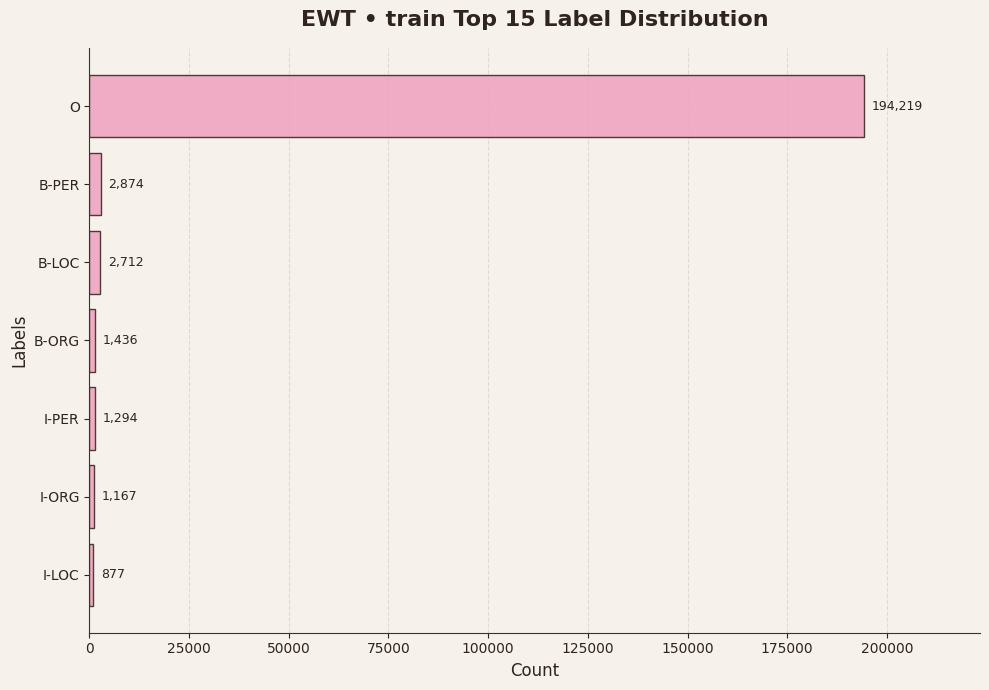

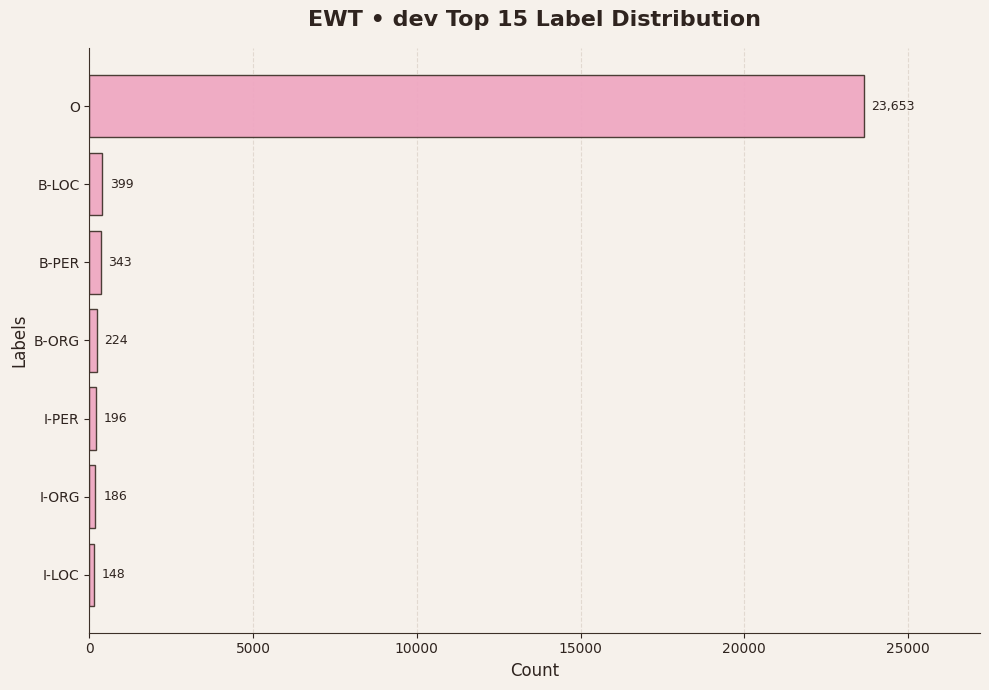

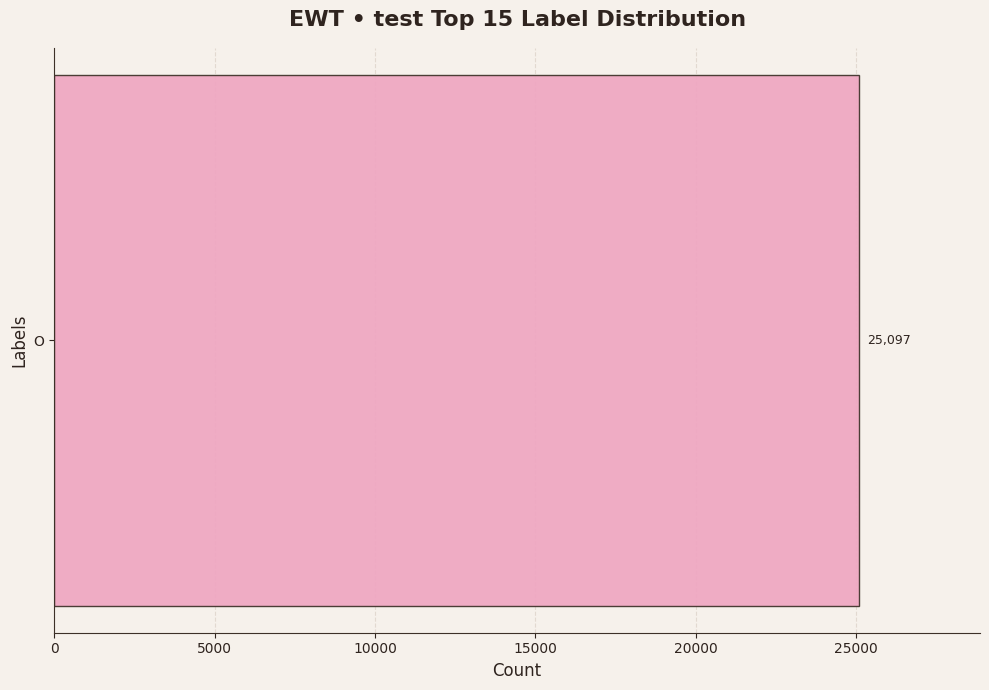

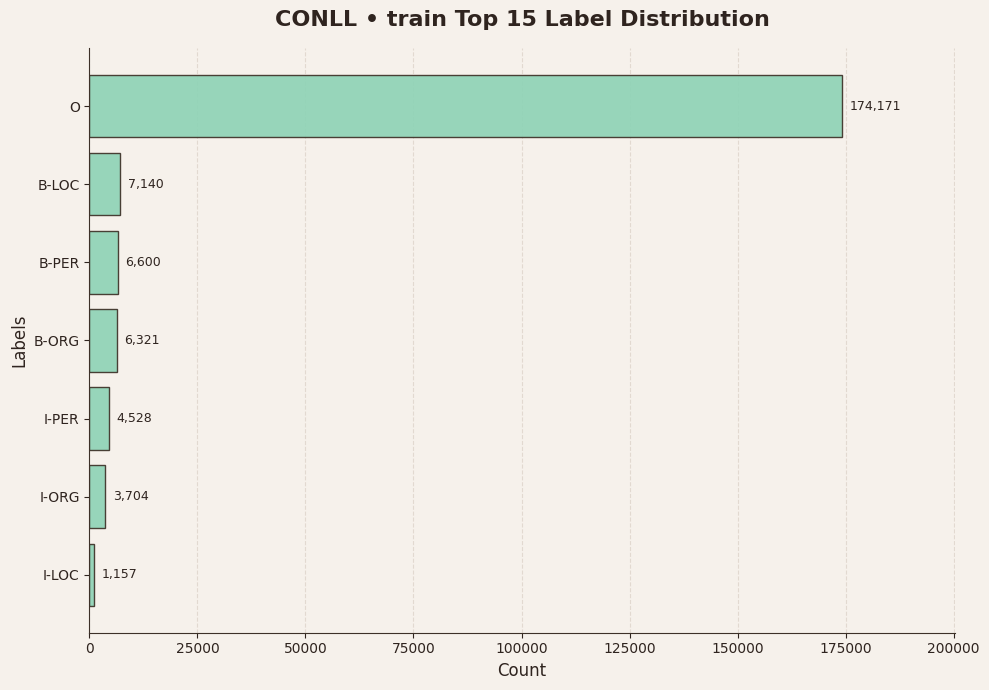

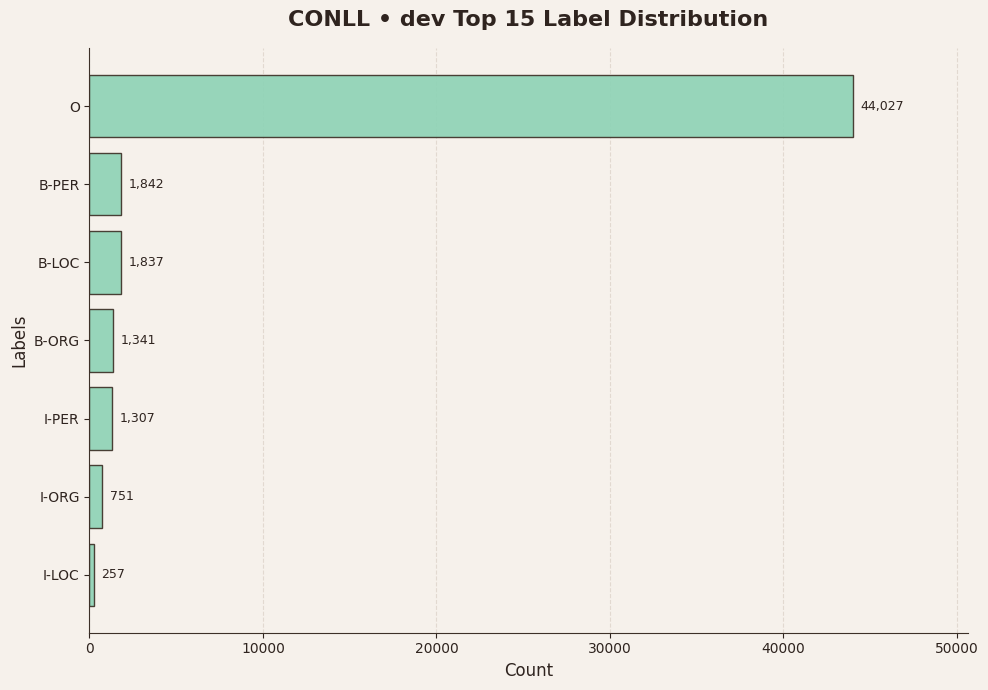

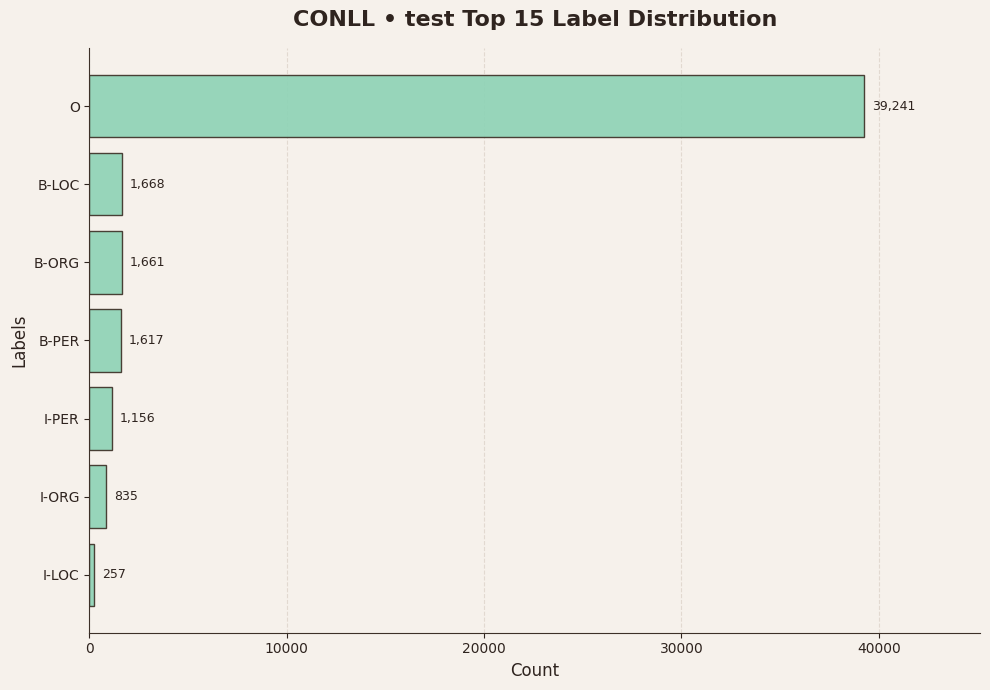

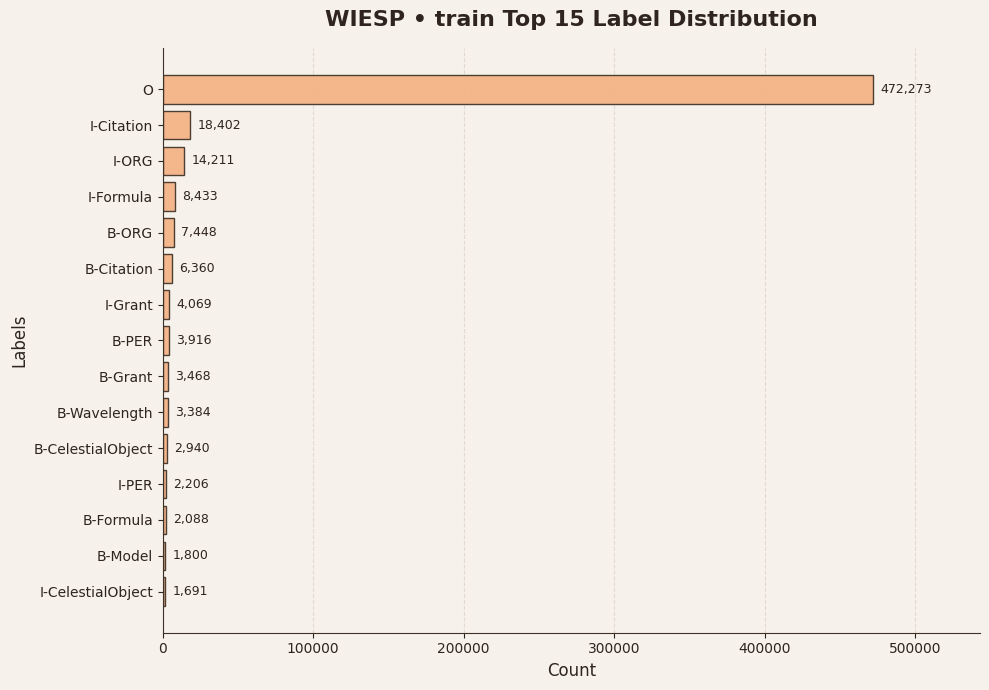

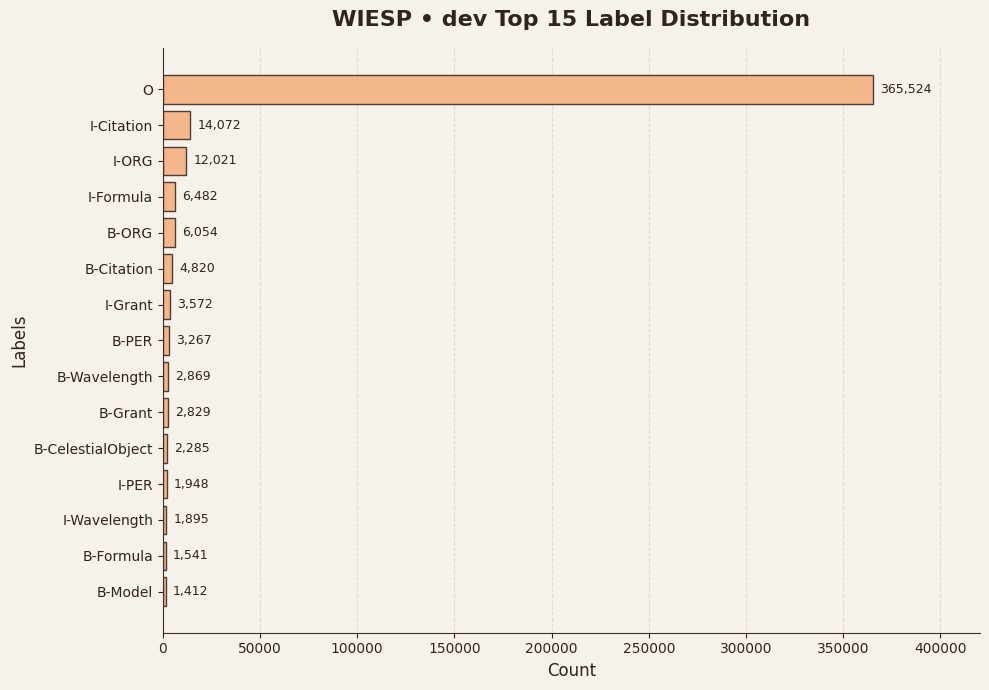

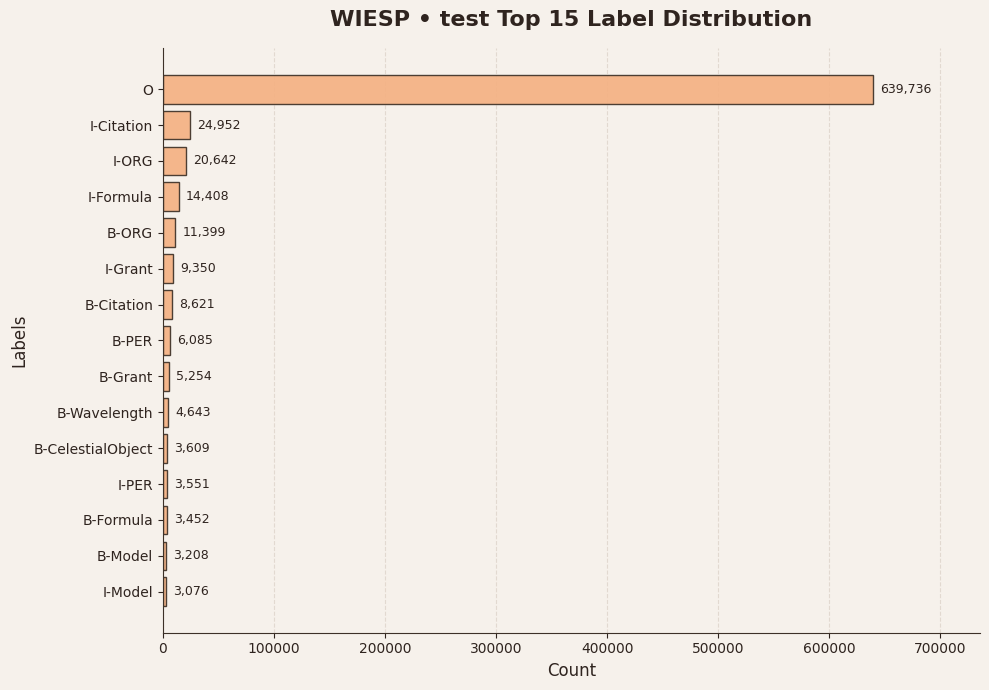

In [50]:

TOP_K = 15

domain_colors = {
    "ewt": "#EFA6C1",
    "conll": "#8FD3B6",
    "wiesp": "#F4B183"
}

for domain, splits in datasets.items():
    for split, data in splits.items():
        label_counter = Counter()

        for sentence in data:
            labels = [normalize_tag(tag) for tag in sentence["ner_tags"]]
            label_counter.update(labels)

        most_common = label_counter.most_common(TOP_K)
        labels, counts = zip(*most_common)

        fig, ax = plt.subplots(figsize=(10, 7))

        fig.patch.set_facecolor("#f6f1eb")
        ax.set_facecolor("#f6f1eb")

        bars = ax.barh(
            labels,
            counts,
            color=domain_colors[domain],
            edgecolor="#3d3128",
            linewidth=1,
            alpha=0.92
        )

        ax.invert_yaxis()

        ax.set_title(
            f"{domain.upper()} • {split} Top {TOP_K} Label Distribution",
            fontsize=16,
            fontweight="bold",
            pad=16,
            color="#2f241f"
        )

        ax.set_xlabel("Count", fontsize=12, color="#2f241f")
        ax.set_ylabel("Labels", fontsize=12, color="#2f241f")

        ax.grid(axis="x", linestyle="--", alpha=0.18, color="#8b6f5a")
        ax.set_axisbelow(True)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#3d3128")
        ax.spines["bottom"].set_color("#3d3128")

        ax.tick_params(axis="x", colors="#2f241f")
        ax.tick_params(axis="y", colors="#2f241f")

        for bar in bars:
            width = bar.get_width()
            ax.text(
                width + max(counts) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{int(width):,}",
                va="center",
                fontsize=9,
                color="#2f241f"
            )

        ax.set_xlim(0, max(counts) * 1.15)

        plt.tight_layout()
        plt.show()